In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

donnees_thermiques = pd.DataFrame({
    "Echantillon": [
        "1-A", "1-B", "1-C", "1-E", "1-F",
        "2-B", "2-D",
        "4-A", "4-C", "4-D", "4-E",
        "5-A", "5-B", "5-C", "5-E", "5-G", "5-H"
    ],

    "Porosite": [
        0.25, 0.12, 0.20, 0.16, 0.11,
        0.25, 0.07,
        0.32, 0.29, 0.26, 0.23,
        0.26, 0.27, 0.21, 0.19, 0.21, 0.21
    ],

    "lambda_100_session_1": [
        0.106704, 0.217692, 0.006408, 0.018352, 0.271094,
        0.115865, 0.005474,
        0.068089, 0.071013, 0.023127, 0.019509,
        0.016263, 0.028934, 0.049588, 0.040705, 0.051441, 0.031648
    ],

    "lambda_100_session_2": [
        0.069023, 0.267875, 0.018331, 0.023703, 0.174152,
        0.144560, 0.055888,
        0.047854, 0.073511, 0.035506, 0.005466,
        0.100926, 0.054285, 0.015845, 0.031084, 0.027993, 0.033218
    ],

    "lambda_50": [
        0.061794, 0.316231, 0.203342, 0.112324, 0.062587,
        0.161472, 0.146130,
        0.058077, 0.125194, 0.057214, 0.065428,
        0.046523, 0.026264, 0.101085, 0.046100, 0.105591, 0.112954
    ]
})

donnees_thermiques["lambda_100_moyenne"] = (
    donnees_thermiques["lambda_100_session_1"]
    + donnees_thermiques["lambda_100_session_2"]
) / 2

donnees_thermiques["demi_ecart_100"] = (
    donnees_thermiques["lambda_100_session_1"]
    - donnees_thermiques["lambda_100_session_2"]
).abs() / 2

display(donnees_thermiques)

,Echantillon,Porosite,lambda_100_session_1,lambda_100_session_2,lambda_50,lambda_100_moyenne,demi_ecart_100
0,1-A,0.25,0.106704,0.069023,0.061794,0.087863,0.018840
1,1-B,0.12,0.217692,0.267875,0.316231,0.242783,0.025091
2,1-C,0.20,0.006408,0.018331,0.203342,0.012370,0.005961
3,1-E,0.16,0.018352,0.023703,0.112324,0.021027,0.002675
4,1-F,0.11,0.271094,0.174152,0.062587,0.222623,0.048471
5,2-B,0.25,0.115865,0.144560,0.161472,0.130213,0.014347
6,2-D,0.07,0.005474,0.055888,0.146130,0.030681,0.025207
7,4-A,0.32,0.068089,0.047854,0.058077,0.057971,0.010117
8,4-C,0.29,0.071013,0.073511,0.125194,0.072262,0.001249
9,4-D,0.26,0.023127,0.035506,0.057214,0.029317,0.006190


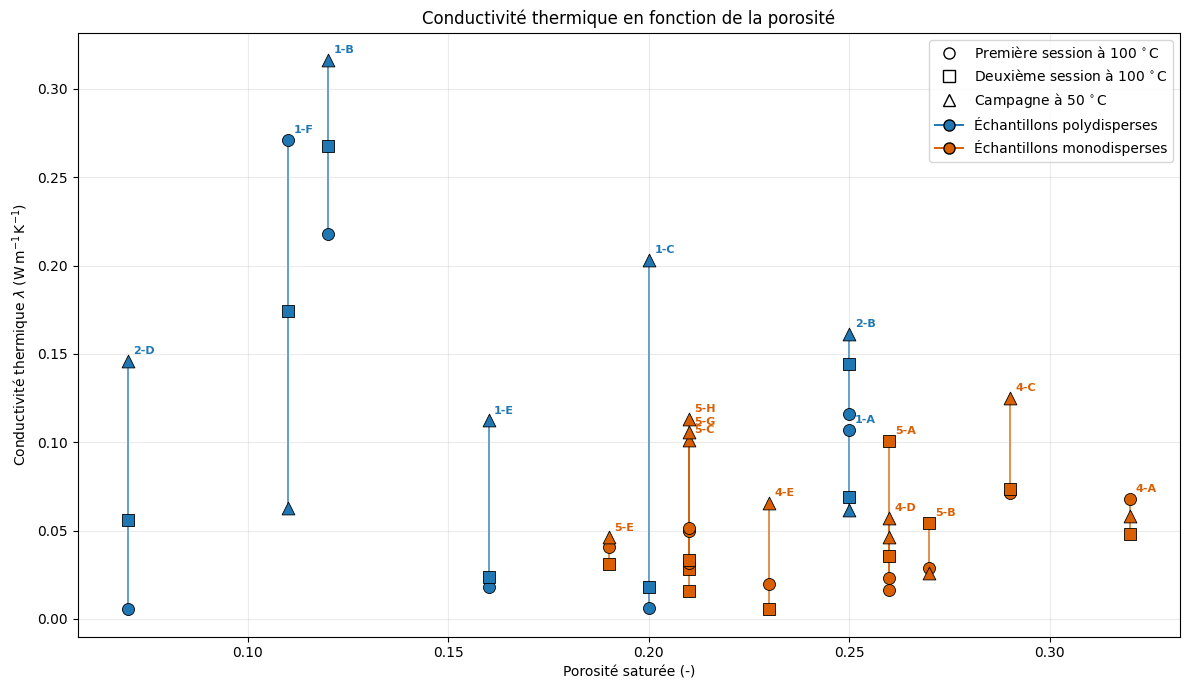

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from google.colab import files

# ============================================================
# CLASSIFICATION
# Séries 1 et 2 : polydisperses
# Séries 4 et 5 : monodisperses
# ============================================================

couleur_polydisperse = "#1f77b4"   # bleu
couleur_monodisperse = "#d95f02"   # orange

couleurs_familles = {
    "Polydisperse": couleur_polydisperse,
    "Monodisperse": couleur_monodisperse
}


def identifier_famille(echantillon):
    numero_serie = int(
        str(echantillon).split("-")[0]
    )

    if numero_serie in [1, 2]:
        return "Polydisperse"

    if numero_serie in [4, 5]:
        return "Monodisperse"

    raise ValueError(
        f"La série de l'échantillon {echantillon} "
        "n'est pas définie."
    )


donnees_plot = donnees_thermiques.copy()

donnees_plot["Famille"] = (
    donnees_plot["Echantillon"]
    .apply(identifier_famille)
)

# ============================================================
# MARQUEURS DES CAMPAGNES
# ============================================================

marqueurs_campagnes = {
    "lambda_100_session_1": "o",
    "lambda_100_session_2": "s",
    "lambda_50": "^"
}

# ============================================================
# CRÉATION DE LA FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

for _, ligne in donnees_plot.iterrows():

    echantillon = ligne["Echantillon"]
    porosite = float(ligne["Porosite"])
    famille = ligne["Famille"]
    couleur = couleurs_familles[famille]

    lambda_100_1 = float(
        ligne["lambda_100_session_1"]
    )

    lambda_100_2 = float(
        ligne["lambda_100_session_2"]
    )

    lambda_50 = float(
        ligne["lambda_50"]
    )

    conductivites = np.array(
        [
            lambda_100_1,
            lambda_100_2,
            lambda_50
        ],
        dtype=float
    )

    # Segment vertical reliant les trois campagnes
    ax.plot(
        [porosite, porosite],
        [
            np.min(conductivites),
            np.max(conductivites)
        ],
        color=couleur,
        linewidth=1.4,
        alpha=0.70,
        zorder=1
    )

    # Première session à 100 °C
    ax.scatter(
        porosite,
        lambda_100_1,
        marker=marqueurs_campagnes["lambda_100_session_1"],
        s=75,
        facecolor=couleur,
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    # Deuxième session à 100 °C
    ax.scatter(
        porosite,
        lambda_100_2,
        marker=marqueurs_campagnes["lambda_100_session_2"],
        s=75,
        facecolor=couleur,
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    # Campagne à 50 °C
    ax.scatter(
        porosite,
        lambda_50,
        marker=marqueurs_campagnes["lambda_50"],
        s=85,
        facecolor=couleur,
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    # Étiquette
    ax.annotate(
        echantillon,
        xy=(
            porosite,
            np.max(conductivites)
        ),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8,
        color=couleur,
        fontweight="bold"
    )

# ============================================================
# LÉGENDE
# ============================================================

legende = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=8,
        label=r"Première session à $100\,^\circ$C"
    ),

    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=8,
        label=r"Deuxième session à $100\,^\circ$C"
    ),

    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=9,
        label=r"Campagne à $50\,^\circ$C"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="-",
        color=couleur_polydisperse,
        markerfacecolor=couleur_polydisperse,
        markeredgecolor="black",
        markersize=8,
        linewidth=1.4,
        label="Échantillons polydisperses"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="-",
        color=couleur_monodisperse,
        markerfacecolor=couleur_monodisperse,
        markeredgecolor="black",
        markersize=8,
        linewidth=1.4,
        label="Échantillons monodisperses"
    )
]

ax.legend(
    handles=legende,
    loc="upper right",
    frameon=True
)

# ============================================================
# MISE EN FORME
# ============================================================

ax.set_xlabel(
    "Porosité saturée (-)"
)

ax.set_ylabel(
    r"Conductivité thermique $\lambda$ "
    r"($\mathrm{W\,m^{-1}\,K^{-1}}$)"
)

ax.set_title(
    "Conductivité thermique en fonction de la porosité"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

# ============================================================
# ENREGISTREMENT
# ============================================================

chemin_pdf = (
    "/content/"
    "conductivite_porosite_mono_polydisperse_corrige.pdf"
)

chemin_png = (
    "/content/"
    "conductivite_porosite_mono_polydisperse_corrige.png"
)

fig.savefig(
    chemin_pdf,
    bbox_inches="tight",
    dpi=300
)

fig.savefig(
    chemin_png,
    bbox_inches="tight",
    dpi=300
)

plt.show()

files.download(chemin_pdf)

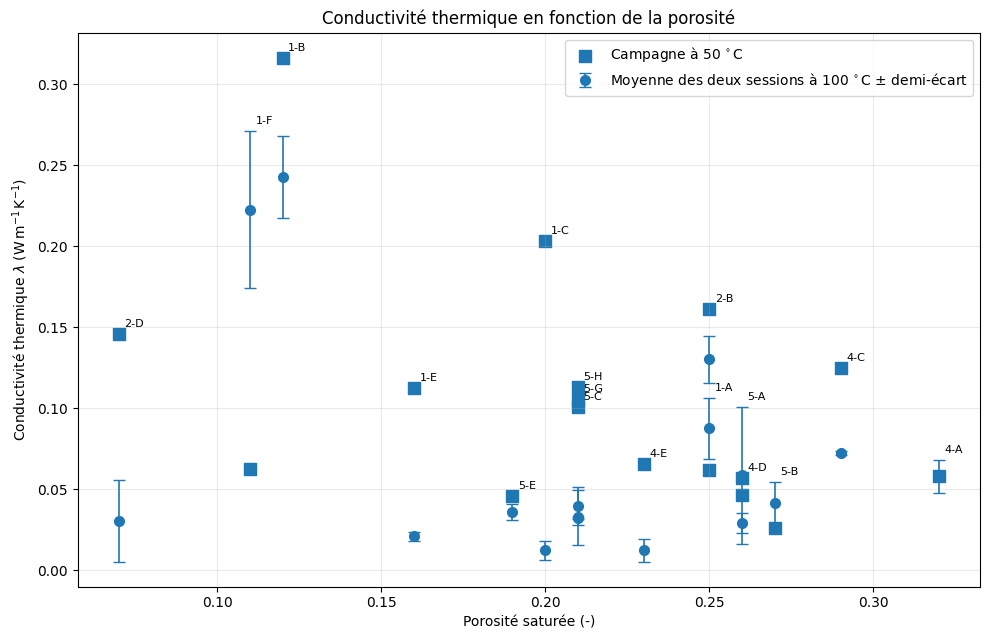

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))

ax.errorbar(
    donnees_thermiques["Porosite"],
    donnees_thermiques["lambda_100_moyenne"],
    yerr=donnees_thermiques["demi_ecart_100"],
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.2,
    label=(
        r"Moyenne des deux sessions à $100\,^\circ$C "
        r"$\pm$ demi-écart"
    )
)

ax.scatter(
    donnees_thermiques["Porosite"],
    donnees_thermiques["lambda_50"],
    marker="s",
    s=65,
    label=r"Campagne à $50\,^\circ$C"
)

for _, ligne in donnees_thermiques.iterrows():
    y_label = max(
        ligne["lambda_100_moyenne"]
        + ligne["demi_ecart_100"],
        ligne["lambda_50"]
    )

    ax.annotate(
        ligne["Echantillon"],
        xy=(ligne["Porosite"], y_label),
        xytext=(4, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Porosité saturée (-)")
ax.set_ylabel(
    r"Conductivité thermique $\lambda$ "
    r"($\mathrm{W\,m^{-1}\,K^{-1}}$)"
)

ax.set_title(
    "Conductivité thermique en fonction de la porosité"
)

ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

chemin_pdf_moyenne = (
    "/content/conductivite_porosite_moyenne_100_et_50.pdf"
)

chemin_png_moyenne = (
    "/content/conductivite_porosite_moyenne_100_et_50.png"
)

fig.savefig(
    chemin_pdf_moyenne,
    bbox_inches="tight",
    dpi=300
)

fig.savefig(
    chemin_png_moyenne,
    bbox_inches="tight",
    dpi=300
)

plt.show()

files.download(chemin_pdf_moyenne)

In [ ]:
correlations = pd.DataFrame({
    "Campagne": [
        "100 °C — session 1",
        "100 °C — session 2",
        "100 °C — moyenne",
        "50 °C"
    ],

    "Pearson": [
        donnees_thermiques[
            ["Porosite", "lambda_100_session_1"]
        ].corr(method="pearson").iloc[0, 1],

        donnees_thermiques[
            ["Porosite", "lambda_100_session_2"]
        ].corr(method="pearson").iloc[0, 1],

        donnees_thermiques[
            ["Porosite", "lambda_100_moyenne"]
        ].corr(method="pearson").iloc[0, 1],

        donnees_thermiques[
            ["Porosite", "lambda_50"]
        ].corr(method="pearson").iloc[0, 1]
    ],

    "Spearman": [
        donnees_thermiques[
            ["Porosite", "lambda_100_session_1"]
        ].corr(method="spearman").iloc[0, 1],

        donnees_thermiques[
            ["Porosite", "lambda_100_session_2"]
        ].corr(method="spearman").iloc[0, 1],

        donnees_thermiques[
            ["Porosite", "lambda_100_moyenne"]
        ].corr(method="spearman").iloc[0, 1],

        donnees_thermiques[
            ["Porosite", "lambda_50"]
        ].corr(method="spearman").iloc[0, 1]
    ]
})

display(correlations.round(3))

,Campagne,Pearson,Spearman
0,100 °C — session 1,-0.324,0.081
1,100 °C — session 2,-0.331,0.053
2,100 °C — moyenne,-0.341,0.146
3,50 °C,-0.451,-0.433


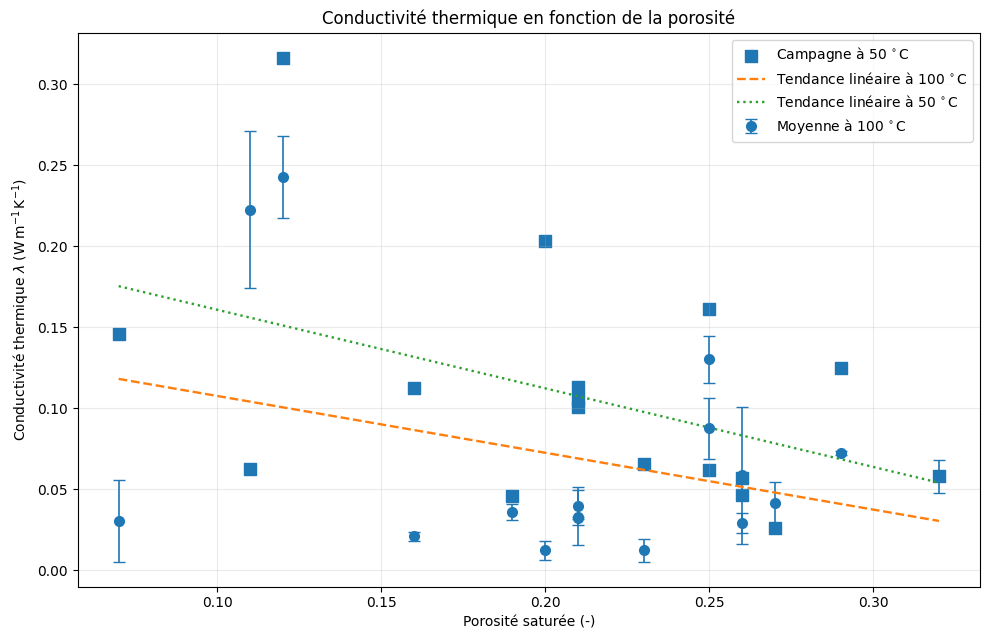

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
phi = donnees_thermiques["Porosite"].to_numpy(dtype=float)

lambda_100 = donnees_thermiques[
    "lambda_100_moyenne"
].to_numpy(dtype=float)

lambda_50 = donnees_thermiques[
    "lambda_50"
].to_numpy(dtype=float)

coefficients_100 = np.polyfit(phi, lambda_100, 1)
coefficients_50 = np.polyfit(phi, lambda_50, 1)

phi_regression = np.linspace(
    phi.min(),
    phi.max(),
    200
)

fig, ax = plt.subplots(figsize=(10, 6.5))

ax.errorbar(
    phi,
    lambda_100,
    yerr=donnees_thermiques["demi_ecart_100"],
    fmt="o",
    markersize=7,
    capsize=4,
    linewidth=1.2,
    label=r"Moyenne à $100\,^\circ$C"
)

ax.scatter(
    phi,
    lambda_50,
    marker="s",
    s=65,
    label=r"Campagne à $50\,^\circ$C"
)

ax.plot(
    phi_regression,
    np.polyval(coefficients_100, phi_regression),
    linestyle="--",
    linewidth=1.7,
    label=r"Tendance linéaire à $100\,^\circ$C"
)

ax.plot(
    phi_regression,
    np.polyval(coefficients_50, phi_regression),
    linestyle=":",
    linewidth=1.7,
    label=r"Tendance linéaire à $50\,^\circ$C"
)

ax.set_xlabel("Porosité saturée (-)")
ax.set_ylabel(
    r"Conductivité thermique $\lambda$ "
    r"($\mathrm{W\,m^{-1}\,K^{-1}}$)"
)

ax.set_title(
    "Conductivité thermique en fonction de la porosité"
)

ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

chemin_pdf_tendances = (
    "/content/conductivite_porosite_avec_tendances.pdf"
)

fig.savefig(
    chemin_pdf_tendances,
    bbox_inches="tight",
    dpi=300
)

plt.show()

files.download(chemin_pdf_tendances)